# 02 - Analisis exploratorio

Distribuciones univariadas, churn rate por segmento, y las dos anomalias de calidad de datos que hay que resolver antes de modelar: `Monthly_Charge` negativo y nulos estructurales en las columnas de servicio.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

DATA_PATH = "../data/Customer_Data.csv"
TARGET_COL = "Customer_Status"
MONTHLY_CHARGE_COL = "Monthly_Charge"
INTERNET_DEPENDENT_COLS = [
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
]

df = pd.read_csv(DATA_PATH)
df_model = df[df[TARGET_COL].isin(["Stayed", "Churned"])].copy()
df_joined = df[df[TARGET_COL] == "Joined"].copy()

## Variables numericas (df_model)

In [2]:
numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months",
    "Monthly_Charge", "Total_Charges", "Total_Revenue",
]
df_model[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6007.0,47.289163,16.805110,18.00,33.000,47.00,60.000,84.00
Number_of_Referrals,6007.0,7.439820,4.622369,0.00,3.000,7.00,11.000,15.00
Tenure_in_Months,6007.0,17.394540,10.592920,1.00,8.000,17.00,27.000,36.00
Monthly_Charge,6007.0,65.087598,31.067808,-10.00,35.950,71.10,90.450,118.75
Total_Charges,6007.0,2430.986173,2267.481294,19.10,539.950,1556.85,4013.900,8684.80
Total_Revenue,6007.0,3233.246021,2856.181082,21.61,833.685,2367.15,5105.685,11979.34


## Churn rate por segmento

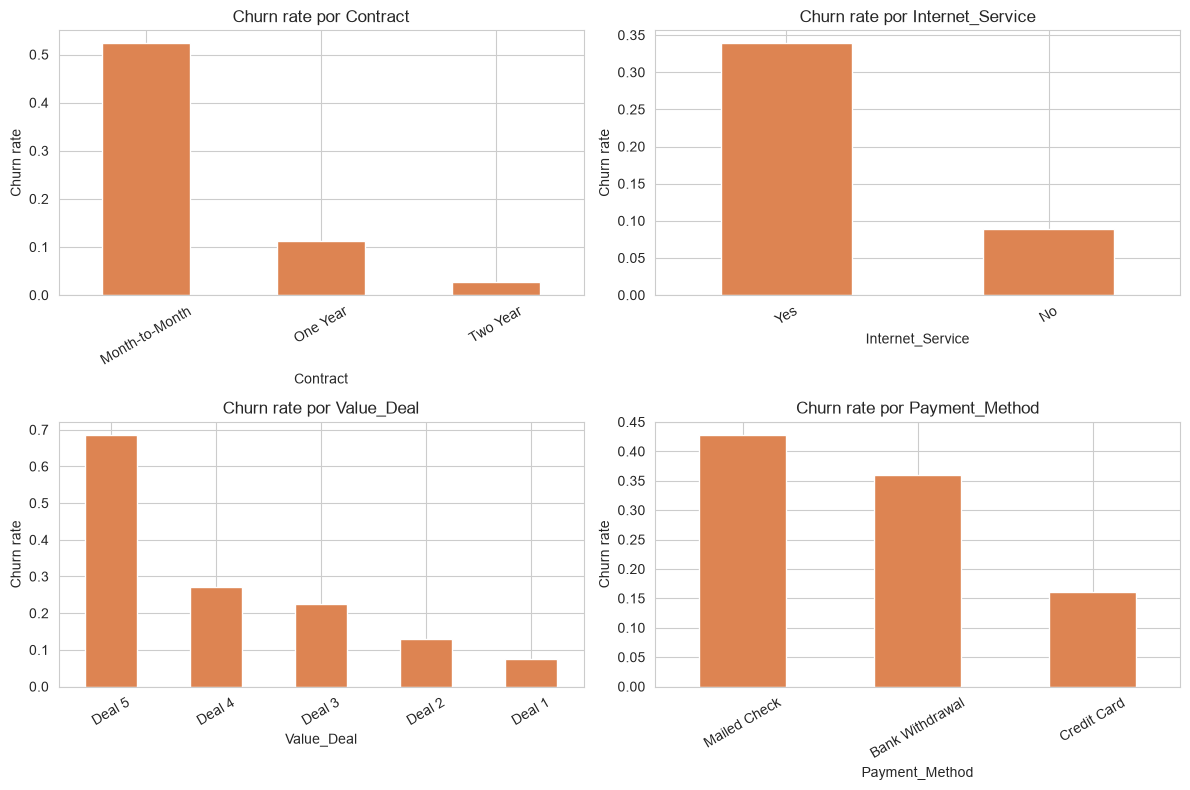

In [3]:
segment_cols = ["Contract", "Internet_Service", "Value_Deal", "Payment_Method"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, segment_cols):
    churn_rate = (
        df_model.groupby(col)[TARGET_COL]
        .apply(lambda s: (s == "Churned").mean())
        .sort_values(ascending=False)
    )
    churn_rate.plot(kind="bar", ax=ax, color="#DD8452")
    ax.set_title(f"Churn rate por {col}")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Anomalia: `Monthly_Charge` negativo

107 filas (1.7%) tienen `Monthly_Charge` negativo, entre -1 y -10, todas enteras -- un patron que apunta a valores sinteticos/sucios, no a cobros reales (ver `CLAUDE.md`). Se excluyen antes de modelar.

In [4]:
negative_mask = df[MONTHLY_CHARGE_COL] < 0
print(f"Filas con Monthly_Charge negativo: {negative_mask.sum()} ({negative_mask.mean():.1%})")
df.loc[negative_mask, MONTHLY_CHARGE_COL].value_counts().sort_index()

Filas con Monthly_Charge negativo: 107 (1.7%)


Monthly_Charge
-10.0    12
-9.0      8
-8.0     12
-7.0     14
-6.0      5
-5.0     11
-4.0     14
-3.0     11
-2.0     10
-1.0     10
Name: count, dtype: int64

## Anomalia: nulos estructurales en columnas de servicio

Las columnas dependientes de internet estan vacias unicamente cuando el cliente no tiene `Internet_Service` -- no es informacion faltante al azar.

In [5]:
internet_no = df_model["Internet_Service"] == "No"

print("Tasa de nulos SIN internet:")
print(df_model.loc[internet_no, INTERNET_DEPENDENT_COLS].isna().mean())

print("\nTasa de nulos CON internet (debe ser ~0):")
print(df_model.loc[~internet_no, INTERNET_DEPENDENT_COLS].isna().mean())

Tasa de nulos SIN internet:
Internet_Type             1.0
Online_Security           1.0
Online_Backup             1.0
Device_Protection_Plan    1.0
Premium_Support           1.0
Streaming_TV              1.0
Streaming_Movies          1.0
Streaming_Music           1.0
Unlimited_Data            1.0
dtype: float64

Tasa de nulos CON internet (debe ser ~0):
Internet_Type             0.0
Online_Security           0.0
Online_Backup             0.0
Device_Protection_Plan    0.0
Premium_Support           0.0
Streaming_TV              0.0
Streaming_Movies          0.0
Streaming_Music           0.0
Unlimited_Data            0.0
dtype: float64


## Resumen

- Los graficos de churn rate por segmento arriba marcan los candidatos a variables predictoras -- se confirman con pruebas de hipotesis en `03_statistical_analysis.ipynb`.
- Dos anomalias de datos confirmadas, a resolver en `04_feature_engineering.ipynb`: `Monthly_Charge` negativo (filtrar) y nulos estructurales (imputar con categoria explicita, no eliminar filas).